Youtube: https://youtu.be/F9uESCHGjhA?si=2UmmeB4YUXSHm8e2

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

In [3]:
X,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col1'])
df['target'] = y
df.shape

(100, 6)

In [6]:
## functions for sampling
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [68]:
import random
def sample_col(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]-1))  ##target column not included
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df[cols]

In [69]:
int(0.25*df.shape[1])

1

In [23]:
## combined Sampling
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_rows(new_df,col_percent)

In [53]:
df1 = sample_rows(df,0.2)

In [54]:
df2 = sample_rows(df,0.2)

In [55]:
df3 = sample_rows(df,0.2)

In [56]:
from sklearn.tree import DecisionTreeClassifier

In [57]:
dt1 = DecisionTreeClassifier()
dt2 = DecisionTreeClassifier()
dt3 = DecisionTreeClassifier()

In [58]:
dt1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
dt2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
dt3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [59]:
from sklearn.tree import plot_tree

[Text(0.2857142857142857, 0.9, 'x[2] <= -0.605\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.14285714285714285, 0.7, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.21428571428571427, 0.8, 'True  '),
 Text(0.42857142857142855, 0.7, 'x[3] <= -0.702\ngini = 0.355\nsamples = 13\nvalue = [3, 10]'),
 Text(0.3571428571428571, 0.8, '  False'),
 Text(0.2857142857142857, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.5714285714285714, 0.5, 'x[4] <= -1.321\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.42857142857142855, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.7142857142857143, 0.3, 'x[3] <= -0.489\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5714285714285714, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8571428571428571, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')]

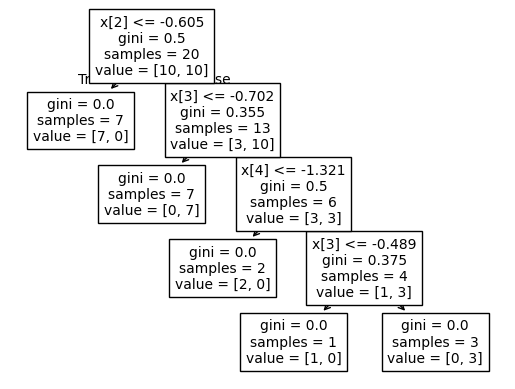

In [60]:
plot_tree(dt1)

[Text(0.6, 0.8333333333333334, 'x[2] <= -0.068\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.4, 0.5, 'x[4] <= -0.788\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.7, 0.6666666666666667, '  False')]

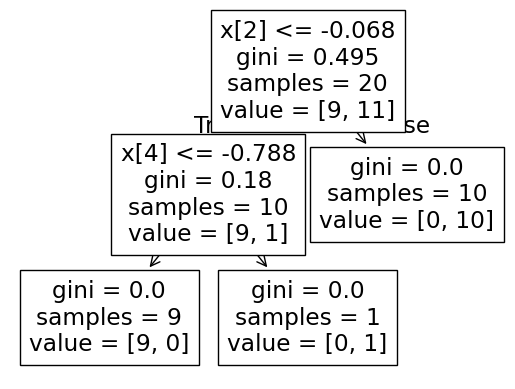

In [61]:
plot_tree(dt2)

[Text(0.4, 0.8333333333333334, 'x[2] <= -0.526\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= -0.979\ngini = 0.298\nsamples = 11\nvalue = [2, 9]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]')]

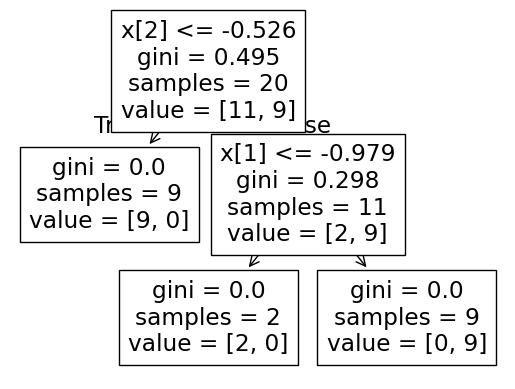

In [62]:
plot_tree(dt3)

In [63]:
dt1.predict(np.array([-2.181040,2.795560,1.791546,-1.587368,-2.535458]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [64]:
dt2.predict(np.array([-2.181040,2.795560,1.791546,-1.587368,-2.535458]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [66]:
dt3.predict(np.array([-2.181040,2.795560,1.791546,-1.587368,-2.535458]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])